In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import random 


import itertools


In [3]:
#Define constants
p_sat = 2.7*10**14 # Saturation density (g/cm^-3)
c = 2.998e8 # Speed of light (m/s)
def convert_gcm3_to_mev_fm3(density_gcm3):
    # Convert g/cm^3 to MeV/fm^3
    density_mev_fm3 = density_gcm3 / (1.7827e12)  
    return density_mev_fm3

p_sat_Mev_fm3 = convert_gcm3_to_mev_fm3(p_sat) # Saturation density in MeV/fm^3


In [4]:
p_sat_Mev_fm3

151.45565714926798

In [5]:
def calculate_P(rho, K, gamma):
    # Calculate the pressure using the equation of state
    return K * (rho**gamma)  # Pressure in MeV/fm^3

def calculate_K(P, rho, gamma):
    # Calculate the K parameter using the equation of state
    return P / (rho**gamma)  # K in MeV/fm^3

def EOS_polytrope(rho, rho_i, gamma_i, K_i,P_i,E_i):
    if gamma_i == 1:
        # Special case for gamma = 1 (non-relativistic)
        return (E_i/rho_i) * rho + K_i * np.log(1/rho_i) * rho - K_i * np.log(1/rho) * rho
    return (E_i/rho_i - P_i/(rho_i * (gamma_i  - 1))) * rho + K_i * rho**gamma_i / (gamma_i - 1)


def NLD(P):
    return 119.05736 + 304.80445 * (1 - np.exp(- P/48.61465)) + 33722.34448 * (1 - np.exp(- P/17499.47411))
    
def PS(P):
    return 9805.95*(1 - np.exp(-0.000193624 * P)) + 212.072 * (1 - np.exp(-0.401508 * P))+ 1.69483
 

In [6]:
P_NLD = NLD(p_sat_Mev_fm3)
P_PS = PS(p_sat_Mev_fm3)
print(f"P_NLD: {P_NLD}, P_PS: {P_PS}")

P_NLD: 700.9439878392125, P_PS: 497.15517383620085


In [7]:
def HLPS_2(P):
    return 172.858 * (1 - np.exp(- P/22.8644)) + 2777.75 * (1 - np.exp(- P/1909.97)) + 161.553
def HLPS_3(P):
    return 131.811 * (1 - np.exp(-P/4.41577)) + 924.143 * (1 - np.exp(- P/523.736)) + 81.5682
print(f"HLPS_2: {HLPS_2(1.722) }, HLPS_3: {HLPS_3(151.668) / p_sat_Mev_fm3}")


HLPS_2: 176.59664666832964, HLPS_3: 2.943007614211516


In [8]:

from scipy.interpolate import CubicSpline
ρ_scatter = np.array([87.07,107.1,118.1,129.9,142.5,155.9,165.3])
P_scatter_HLPS2 = [0.4470,0.7162,0.9094,1.154,1.464,1.851,2.163]
P_scatter_HLPS3 = [0.6960,1.150,1.473,1.880,2.392,3.028,3.542]

In [9]:
spl_HLPS_2 = CubicSpline(ρ_scatter,P_scatter_HLPS2)
spl_HLPS_3 = CubicSpline(ρ_scatter,P_scatter_HLPS3)
ρ_sat_MeV = p_sat_Mev_fm3 # Saturation density in MeV/fm^3
# Defining a range of mass density values
ρ_range = np.linspace(ρ_scatter[0],ρ_scatter[-1],200)
P_saturation_HLPS_2 = spl_HLPS_2(ρ_sat_MeV)
P_saturation_HLPS_3 = spl_HLPS_3(ρ_sat_MeV)


plt.show()

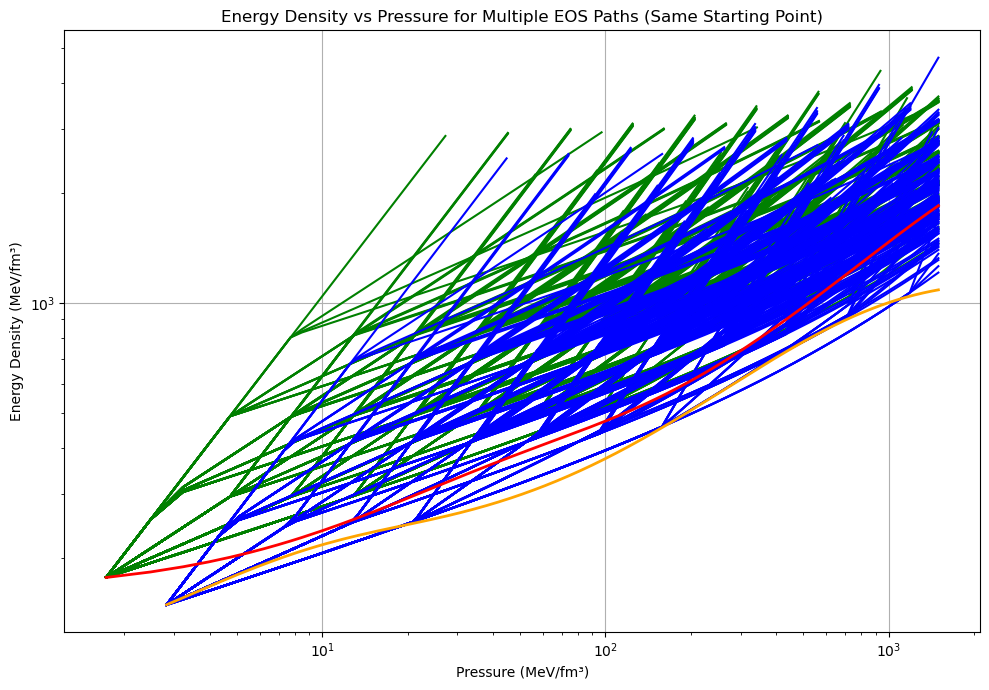

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# Constants
r_sat = 2.7e14  # g/cm^3
c = 2.998e8
MeV_to_J = 1.60218e-13

# Helper conversion
def conv_to_MeV(value):
    result = value * 1e3  # kg/m^3
    result = result * c**2  # J/m^3
    result = result / MeV_to_J  # MeV/m^3
    result = result * 1e-45  # MeV/fm^3
    return result

def HLPS_2(P):
    return 172.858 * (1 - np.exp(- P/22.8644)) + 2777.75 * (1 - np.exp(- P/1909.97)) + 161.553

# EOS Class
class EOSPath:
    def __init__(self, P0, E0, segment_densities, gammas, name="EOS"):
        self.segment_densities = np.array(segment_densities)
        self.gammas = np.array(gammas)
        self.P0 = P0
        self.E0 = E0
        self.name = name
        self.Pi = []
        self.Ei = []
        self.K_list = []
        self.linear_start = None
        self.linear_eps = None

    def calculate_K(self, P, rho, gamma):
        return P / rho ** gamma

    def calculate_P(self, rho, K, gamma):
        return K * rho ** gamma

    def calculate_E(self, P, Ki, gamma, rho_i, P_i, E_i):
        if gamma == 1:
            return (E_i / rho_i) * P / Ki + np.log(1 / rho_i) * P - P * np.log(Ki / P)
        else:
            return (E_i / rho_i - P_i / (rho_i * (gamma - 1))) * (P / Ki) ** (1 / gamma) + P / (gamma - 1)

    def dE_dP(self, P, Ki, gamma, rho_i, P_i, E_i):
        if gamma == 1:
            return E_i / (rho_i * Ki) + np.log(1 / rho_i) + 1 - np.log(Ki / P)
        else:
            return (1 / (Ki * gamma)) * (E_i / rho_i - P_i / (rho_i * (gamma - 1))) * (P / Ki) ** (1 / gamma - 1) + 1 / (gamma - 1)

    def EOS_Linear(self, P, P_transition, E_transition):
        
        return E_transition + (P - P_transition)
    
    def calculate_parameters(self):
        # Initialize storage lists
        Pi_vals = [self.P0]
        Ei_vals = [self.E0]
        Ki_vals = []

        n = len(self.gammas)

        # Calculate Pi, Ei, Ki arrays for each segment
        for i in range(n):
            gamma = self.gammas[i]
            rho_i = self.segment_densities[i]
            rho_next = self.segment_densities[i + 1]

            K_i = self.calculate_K(Pi_vals[i], rho_i, gamma)
            Ki_vals.append(K_i)

            P_next = self.calculate_P(rho_next, K_i, gamma)
            Ei_next = self.calculate_E(P_next, K_i, gamma, rho_i, Pi_vals[i], Ei_vals[i])

            Pi_vals.append(P_next)
            Ei_vals.append(Ei_next)

        # Fine pressure sampling for slope checking
        P_range = np.linspace(Pi_vals[0], Pi_vals[-1], 10000)
        P_tr = None
        E_tr = None

        # Function to compute slope dE/dP for piecewise polytropic EOS at arbitrary P
        def slope_at_P(P):
            # Find which segment P belongs to
            for i in range(len(Pi_vals) - 1):
                if Pi_vals[i] <= P <= Pi_vals[i + 1]:
                    return self.dE_dP(P, Ki_vals[i], self.gammas[i], self.segment_densities[i], Pi_vals[i], Ei_vals[i])
            # If beyond known segments, assume linear EOS slope = 1
            if self.linear_start and P > self.linear_start:
                return 1
            return 1  # fallback

        # Find the first pressure where slope < 1 (causality violation)
        for P in P_range:
            slope = slope_at_P(P)
            if slope < 0.005:
                P_tr = P
                # Calculate corresponding energy at transition
                for i in range(len(Pi_vals) - 1):
                    if Pi_vals[i] <= P_tr <= Pi_vals[i + 1]:
                        E_tr = self.calculate_E(P_tr, Ki_vals[i], self.gammas[i], self.segment_densities[i], Pi_vals[i], Ei_vals[i])
                        break
                # Truncate lists at transition
                for idx, P_bound in enumerate(Pi_vals):
                    if P_bound >= P_tr:
                        Pi_vals = Pi_vals[:idx + 1]
                        Ei_vals = Ei_vals[:idx + 1]
                        Pi_vals[-1] = P_tr
                        Ei_vals[-1] = E_tr
                        break
                break

        # Save results to the object
        self.Pi = Pi_vals
        self.Ei = Ei_vals
        self.K_list = Ki_vals
        self.linear_start = P_tr
        self.linear_eps = E_tr
 
 
    def get_energy_from_pressure(self, P):
        for i in range(len(self.Pi) - 1):
            if self.Pi[i] <= P <= self.Pi[i + 1]:
                return self.calculate_E(P, self.K_list[i], self.gammas[i], self.segment_densities[i], self.Pi[i], self.Ei[i])
        # if P > self.Pi[-1]:
        #     # if self.linear_start is None or self.linear_eps is None:
        #     #     # fallback if linear start/eps not set
        #     #     return self.Ei[-1]  # or some other reasonable fallback
        #     return self.calculate_E(P, self.K_list[i], self.gammas[i], self.segment_densities[i], self.Pi[i], self.Ei[i]) + P - self.Pi[-1]
        
def get_segment_rhos(gamma_1, num_segments):
    ρ_sat_MeV = conv_to_MeV(r_sat)
    if gamma_1 <= 2:
        ρ_high = 16 * ρ_sat_MeV
    elif 2 < gamma_1 <= 3:
        ρ_high = 12 * ρ_sat_MeV
    else:
        ρ_high = 9 * ρ_sat_MeV

    log_ρ0 = np.log(ρ_sat_MeV)
    log_ρn = np.log(7.5 * ρ_sat_MeV)
    segment_rhos = np.exp(np.linspace(log_ρ0, log_ρn, num_segments + 1))
    segment_rhos[-1] = ρ_high
    return segment_rhos         

# Setup: Ensure all EOS paths start from the same pressure and energy density
P_sat = 1.722  # Starting pressure
E_sat = HLPS_2(P_sat)  # Starting energy density
r_sat_Mev_fm3 = conv_to_MeV(r_sat)  # Initial density in MeV/fm³



# Define pressure array P (for example)
P_array_2 = np.linspace(P_sat, 1500, 2000)  # Adjust size for desired resolution

# Plot energy densities for each EOS path
plt.figure(figsize=(10, 7))


# Plot all EOS paths ensuring they start from the same point
# Mask P_array to start at P_sat
P_array_masked_2 = P_array_2[P_array_2 >= P_sat]

# Plot all EOS paths ensuring they start from the same point
P_sat_2 = 1.722
# P_sat = 1.722 # in MeV/fm^3
P_sat_3 = 2.816 # in MeV/fm^3
E_sat_2 = HLPS_2(P_sat_2)
E_sat_3 = HLPS_3(P_sat_3)
segments = 4
gamma_options = [1,2,3,4]


P_array_3 = np.linspace(P_sat_3, 1500, 2000) 
P_array_masked_3 = P_array_3[P_array_3 >= P_sat_3]


all_gamma_paths = list(product(gamma_options, repeat=segments))
eos_jobs = []
for idx, gamma_path in enumerate(all_gamma_paths):
    gamma_1 = gamma_path[0]
    segment_rhos = get_segment_rhos(gamma_1, segments)
    model_name = f"EOS_{idx + 1}"
    eos = EOSPath(P_sat_2, E_sat_2, segment_rhos, gamma_path, name=model_name)
    eos.calculate_parameters()

    # Compute energy densities only for P >= P_sat
    energy_densities = [eos.get_energy_from_pressure(P) for P in P_array_masked_2]

    # Filter out None values
    valid = np.array([e is not None for e in energy_densities])
    if np.any(valid):
        plt.loglog(P_array_masked_2[valid], np.array(energy_densities)[valid], color='green')

for idx, gamma_path in enumerate(all_gamma_paths):
    gamma_1 = gamma_path[0]
    segment_rhos = get_segment_rhos(gamma_1, segments)
    model_name = f"EOS_{idx + 1}"
    eos = EOSPath(P_sat_3, E_sat_3, segment_rhos, gamma_path, name=model_name)
    eos.calculate_parameters()

    # Compute energy densities only for P >= P_sat
    energy_densities = [eos.get_energy_from_pressure(P) for P in P_array_masked_3]

    # Filter out None values
    valid = np.array([e is not None for e in energy_densities])
    if np.any(valid):
        plt.loglog(P_array_masked_3[valid], np.array(energy_densities)[valid], color='blue')
        
# Plot HLPS-2 EOS starting from P_sat only
hlps_values = HLPS_2(P_array_masked_2)
plt.loglog(P_array_masked_2, hlps_values, color='red', lw=2, label="HLPS-2")
hlps_values = HLPS_3(P_array_masked_3)
plt.loglog(P_array_masked_3, hlps_values, color='orange', lw=2, label="HLPS-3")
plt.xlabel("Pressure (MeV/fm³)")
plt.ylabel("Energy Density (MeV/fm³)")
plt.title("Energy Density vs Pressure for Multiple EOS Paths (Same Starting Point)")
plt.grid(True)
plt.tight_layout()
# plt.legend(fontsize="x-small", loc="upper left", ncol=2)
plt.show()


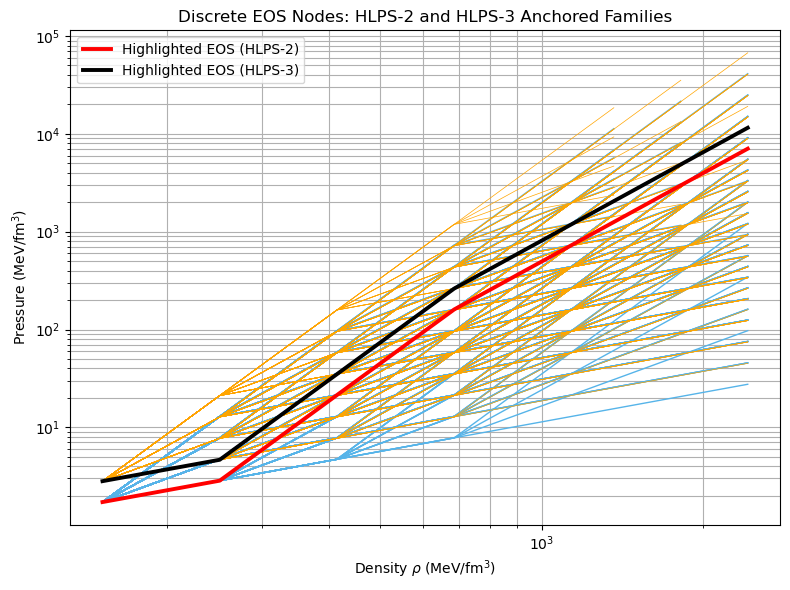

In [14]:
plt.figure(figsize=(8, 6))

# Choose one EOS to highlight (example)
highlight_gamma = (1,4,4,3)

# ==========================
# HLPS-2 anchored EOS family
# ==========================
for gamma_path in all_gamma_paths:
    gamma_1 = gamma_path[0]
    segment_rhos = get_segment_rhos(gamma_1, segments)

    eos = EOSPath(P_sat_2, E_sat_2, segment_rhos, gamma_path)
    eos.calculate_parameters()

    Pi = np.array(eos.Pi)
    rho_i = np.array(eos.segment_densities[:len(Pi)])  # 🔑 FIX

    if gamma_path == highlight_gamma:
        plt.loglog(
            rho_i, Pi,
            color="red", lw=2.8,
            label="Highlighted EOS (HLPS-2)", zorder=10
        )
    else:
        plt.loglog(
            rho_i, Pi,
            color="#56B4E9", lw=1
        )

# ==========================
# HLPS-3 anchored EOS family
# ==========================
for gamma_path in all_gamma_paths:
    gamma_1 = gamma_path[0]
    segment_rhos = get_segment_rhos(gamma_1, segments)

    eos = EOSPath(P_sat_3, E_sat_3, segment_rhos, gamma_path)
    eos.calculate_parameters()

    Pi = np.array(eos.Pi)
    rho_i = np.array(segment_rhos[:len(eos.Pi)])  # 🔑 FIX

    if gamma_path == highlight_gamma:
        plt.loglog(
            rho_i, Pi,
            color="black", lw=2.8,
            label="Highlighted EOS (HLPS-3)", zorder=10
        )
    else:
        plt.loglog(
            rho_i, Pi,
            color="orange", lw=0.5
            
        )

# ==========================
# Plot styling
# ==========================
plt.xlabel(r"Density $\rho$ (MeV/fm$^3$)")
plt.ylabel(r"Pressure (MeV/fm$^3$)")
plt.title("Discrete EOS Nodes: HLPS-2 and HLPS-3 Anchored Families")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()


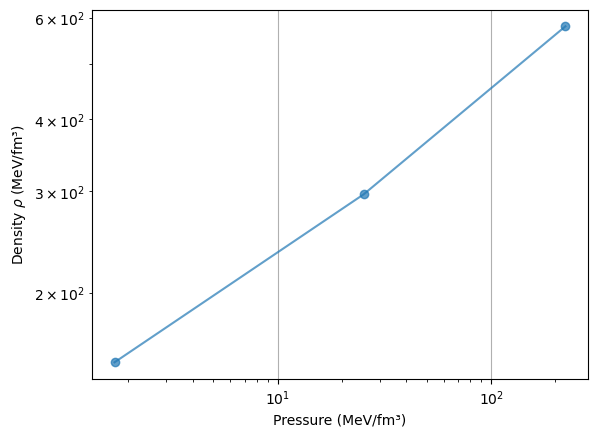

In [109]:
Pi = np.array(eos.Pi)
rho_nodes = []

for i in range(len(Pi)):
    rho_nodes.append(eos.segment_densities[i])

rho_nodes = np.array(rho_nodes)

plt.loglog(Pi, rho_nodes, "o-", alpha=0.7)
plt.xlabel("Pressure (MeV/fm³)")
plt.ylabel(r"Density $\rho$ (MeV/fm³)")
plt.grid(True)
plt.show()


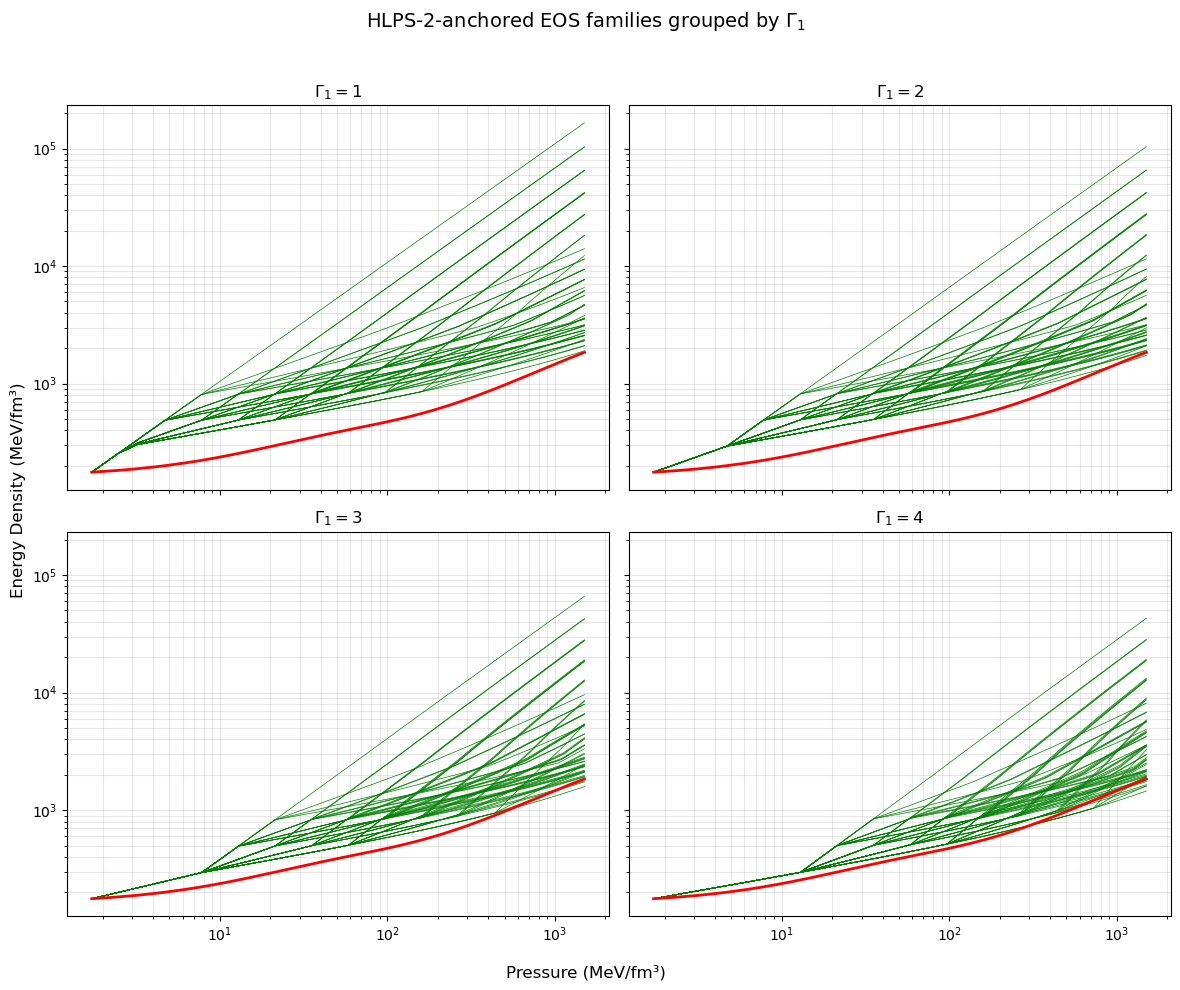

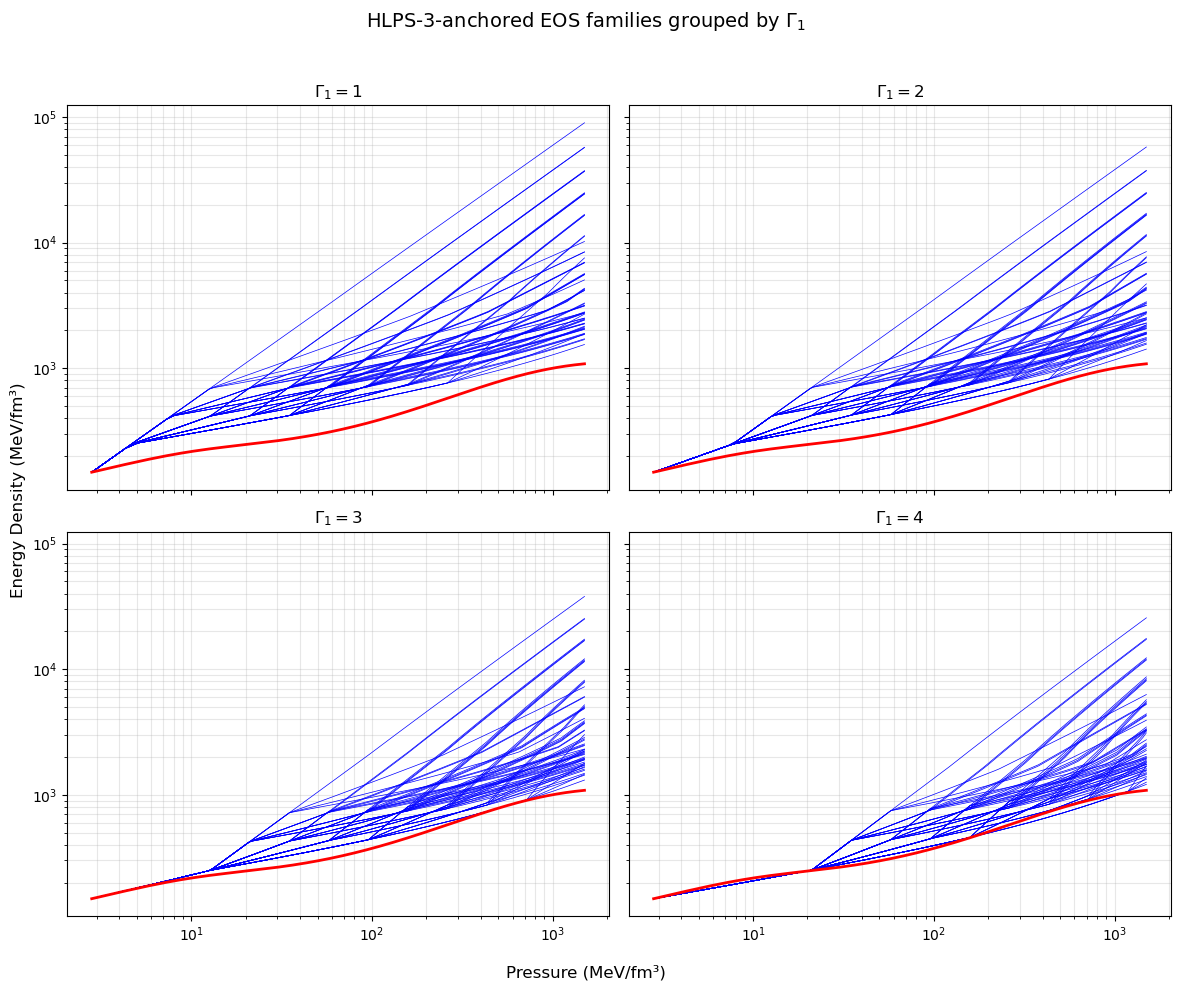

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from collections import defaultdict

# ==========================================================
# Group gamma paths by starting gamma
# ==========================================================
gamma_groups = defaultdict(list)
for gamma_path in all_gamma_paths:
    gamma_groups[gamma_path[0]].append(gamma_path)

# ==========================================================
# Function to plot EOS families in subplots
# ==========================================================
def plot_eos_subplots(
    P_sat, E_sat, P_array_masked, HLPS_func,
    color_eos, title_prefix
):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, (gamma1, paths) in zip(axes, gamma_groups.items()):

        for gamma_path in paths:
            segment_rhos = get_segment_rhos(gamma1, segments)
            eos = EOSPath(P_sat, E_sat, segment_rhos, gamma_path)
            eos.calculate_parameters()

            energy = [eos.get_energy_from_pressure(P) for P in P_array_masked]
            valid = np.array([e is not None for e in energy])

            if np.any(valid):
                ax.loglog(
                    P_array_masked[valid],
                    np.array(energy)[valid],
                    color=color_eos,
                    lw=0.5
                )

        # HLPS reference
        ax.loglog(
            P_array_masked,
            HLPS_func(P_array_masked),
            color="red",
            lw=2,
            label=title_prefix
        )

        ax.set_title(rf"$\Gamma_1 = {gamma1}$")
        ax.grid(True, which="both", alpha=0.3)

    fig.suptitle(
        f"{title_prefix}-anchored EOS families grouped by $\\Gamma_1$",
        fontsize=14
    )
    fig.supxlabel("Pressure (MeV/fm³)")
    fig.supylabel("Energy Density (MeV/fm³)")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# ==========================================================
# Plot HLPS-2 EOS families
# ==========================================================
plot_eos_subplots(
    P_sat=P_sat_2,
    E_sat=E_sat_2,
    P_array_masked=P_array_masked_2,
    HLPS_func=HLPS_2,
    color_eos="green",
    title_prefix="HLPS-2"
)

# ==========================================================
# Plot HLPS-3 EOS families
# ==========================================================
plot_eos_subplots(
    P_sat=P_sat_3,
    E_sat=E_sat_3,
    P_array_masked=P_array_masked_3,
    HLPS_func=HLPS_3,
    color_eos="blue",
    title_prefix="HLPS-3"
)
